In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

epiconfig= EpiConfig(
        disease             = 'influenza',

        split_berlin        = False,

        horizon_leadtime    = 3,
        sequence_length     = 4,

        feature_popsize     = True,      
        feature_popdens     = True,
        feature_gisd        = True,
        feature_popage      = True,
        feature_kreise_classes= True,
        
        log_transform       = ['incidence']     
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

In [2]:
from src.dataloading import BaseLineDataLoaderManager, DeepDataLoaderManager

n_epochs        = 1
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()


==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 39, 4), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8762   |   1.4077   |    v     |           |
trained ✓


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


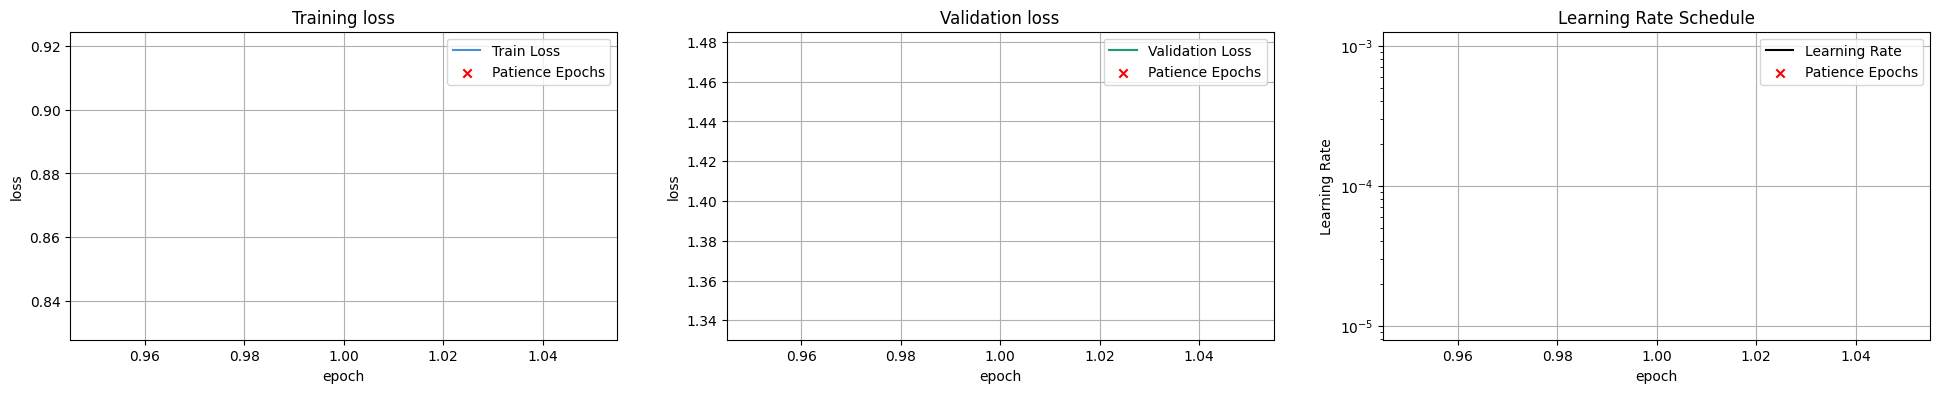

In [3]:
from src.models import LSTMModel

lstm = LSTMModel(deepdataloader, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train()
# lstm.forecast('test')
# lstm.show_forecasts(26)


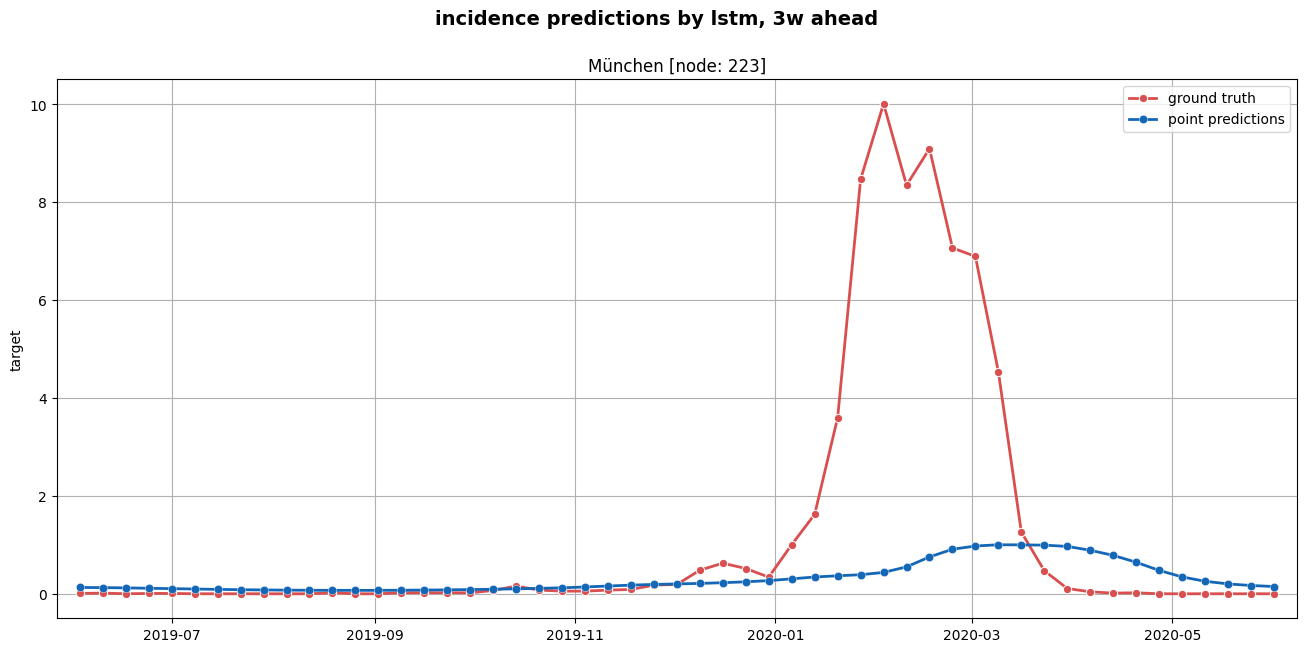

In [5]:
lstm.show_forecasts(223,'test').show()

In [ ]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()

climascale = ClimaScaleModel(baselinedataloader)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:08<00:00,  1.45s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

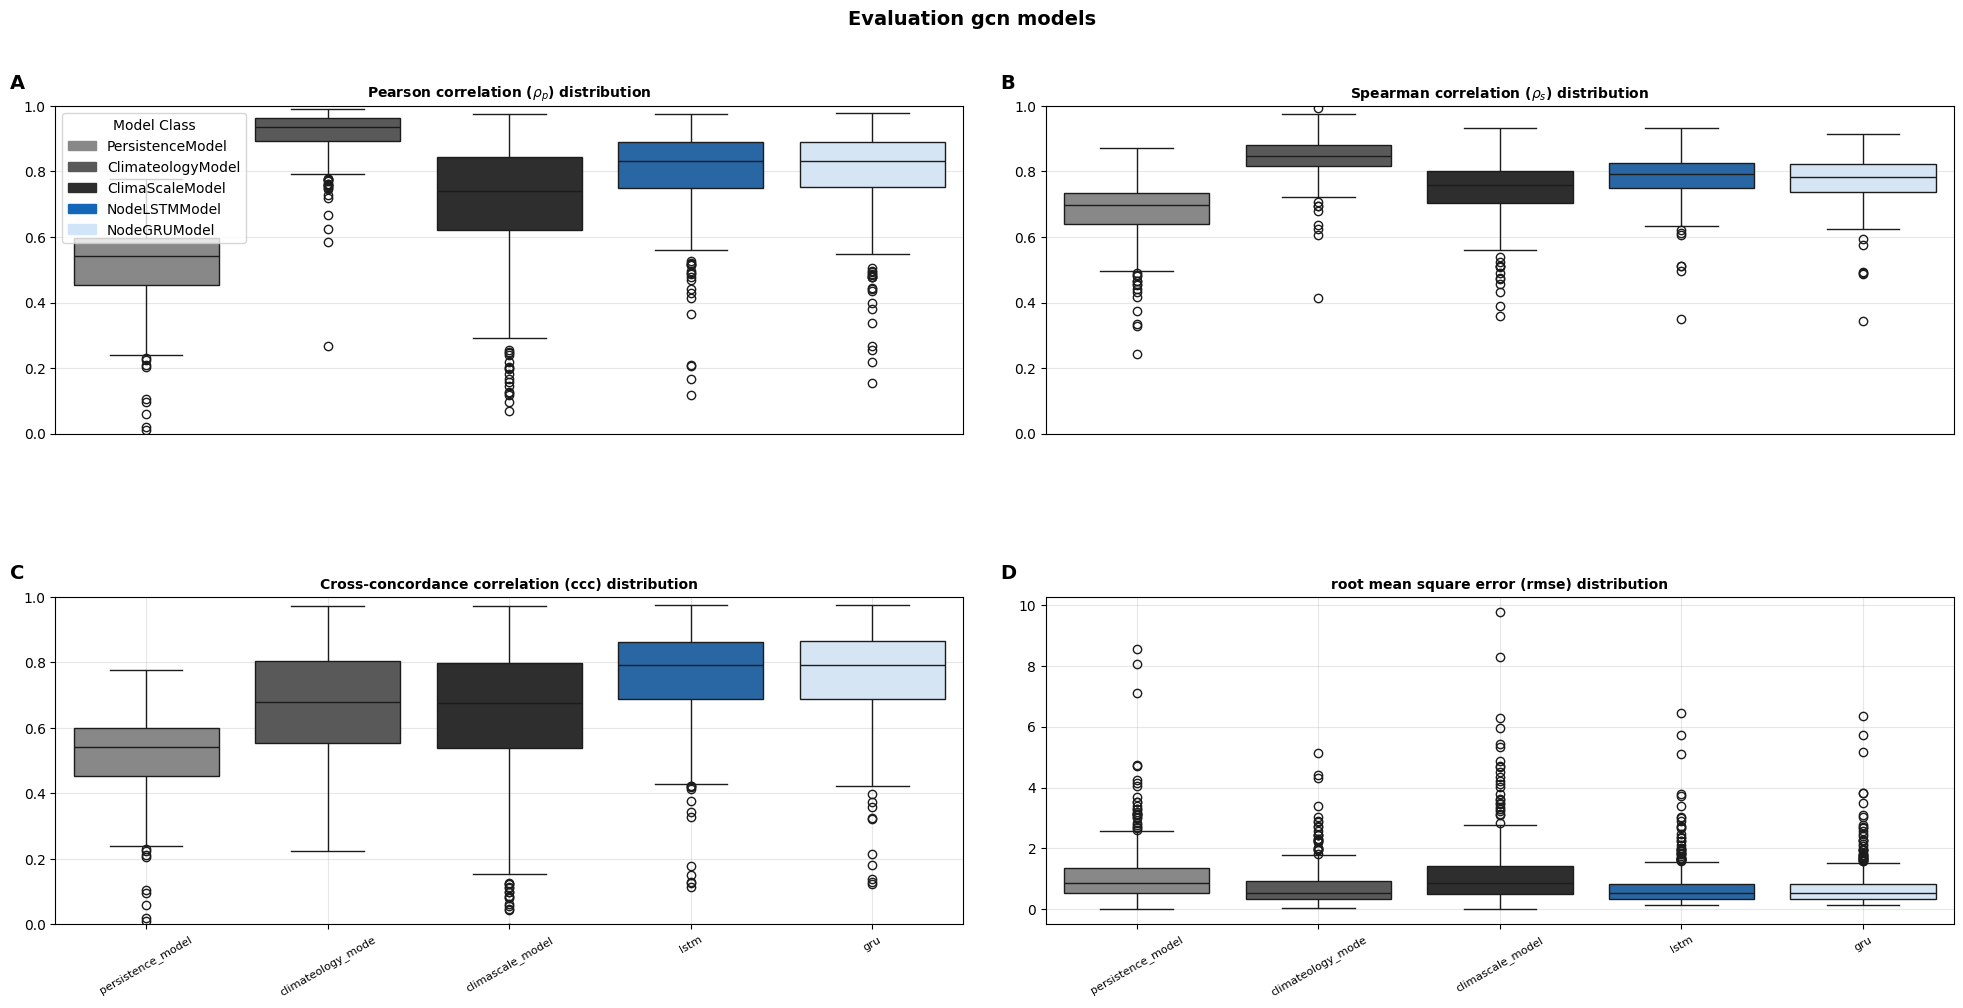

In [ ]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [lstm,gru]).add_evaluation()
f_merged_raw    = evaluation_experiment_sgnn.plotter.plot_metric_compilation(subfig_size = (8,4), plot_types = ['box','box','box','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()